# Spotify Hit Predictor - Popularity Tier Classification Model


## Phase 1 - Feature Engineering & Data Preprocessing


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\DELL\Desktop\what-makes-a-hit\spotify_deduplicated.csv")
df_original = df.copy()

In [2]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_tier,is_dead_track
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Hit,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Mid,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Mid,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Hit,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Viral,0


In [3]:
features = ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 'track_genre']
x = df[features].copy()
y_raw = df ['popularity']

In [4]:
le = LabelEncoder()
x['track_genre'] = le.fit_transform(x['track_genre'])

bins = [-1, 19, 49, 79, 100]
labels = ['Flop', 'Mid', 'Hit', 'Viral']
y = pd.cut(y_raw, bins=bins, labels=labels)

In [5]:
print('New Class Distribution:')
print(y.value_counts())

New Class Distribution:
popularity
Mid      43477
Hit      18841
Flop     17541
Viral      539
Name: count, dtype: int64


**Phase 2** - Handling Imbalance and Splitting Data

In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Resampled Training Class Distribution:')
print(pd.Series(y_train_resampled).value_counts())

Resampled Training Class Distribution:
popularity
Flop     34781
Mid      34781
Hit      34781
Viral    34781
Name: count, dtype: int64


**Phase 3 - Selecting and Training the Model**

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)

In [9]:
model.fit(X_train_resampled, y_train_resampled)
print("Training the model...this may take a moment...")

Training the model...this may take a moment...


In [10]:
y_pred = model.predict(X_test)
print("\nModel Evaluation Report:")
print(classification_report(y_test, y_pred))


Model Evaluation Report:
              precision    recall  f1-score   support

        Flop       0.57      0.56      0.56      3508
         Hit       0.47      0.51      0.49      3768
         Mid       0.72      0.68      0.70      8696
       Viral       0.09      0.23      0.13       108

    accuracy                           0.61     16080
   macro avg       0.46      0.49      0.47     16080
weighted avg       0.62      0.61      0.61     16080



In [11]:
df['explicit_genre'] = df['track_genre'] + '_' + df['explicit'].map({True: 'explicit', False: 'clean'})

In [12]:
print(df['explicit_genre'].value_counts().head(10))

explicit_genre
study_clean            996
bluegrass_clean        973
cantopop_clean         953
disney_clean           951
new-age_clean          951
forro_clean            950
idm_clean              945
chicago-house_clean    939
afrobeat_clean         937
tango_clean            935
Name: count, dtype: int64


In [13]:
features = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'tempo',
    'track_genre',
    'explicit_genre',
    'is_dead_track'
]

x = df[features].copy()

In [14]:
df['is_dead_track'] = df['popularity'] == 0
x['is_dead_track'] = df['is_dead_track'].astype(int)

Re-training the Model

In [15]:
le_genre = LabelEncoder()
le_explicit_genre = LabelEncoder()

x = df[features].copy()
x['track_genre'] = le_genre.fit_transform(x['track_genre'])
x['explicit_genre'] = le_explicit_genre.fit_transform(x['explicit_genre'])

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("Balanced successfully with new features.")

Balanced successfully with new features.


In [17]:
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(x_train_resampled, y_train_resampled)

y_pred_v2 = model_v2.predict(x_test)
print("\nModel Evaluation Report with New Features:")
print(classification_report(y_test, y_pred_v2))




Model Evaluation Report with New Features:
              precision    recall  f1-score   support

        Flop       0.77      0.74      0.75      3508
         Hit       0.53      0.61      0.57      3768
         Mid       0.77      0.72      0.75      8696
       Viral       0.08      0.23      0.12       108

    accuracy                           0.70     16080
   macro avg       0.54      0.58      0.55     16080
weighted avg       0.71      0.70      0.70     16080



C:\Users\DELL\AppData\Local\Temp\ipykernel_4496\3844594271.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')


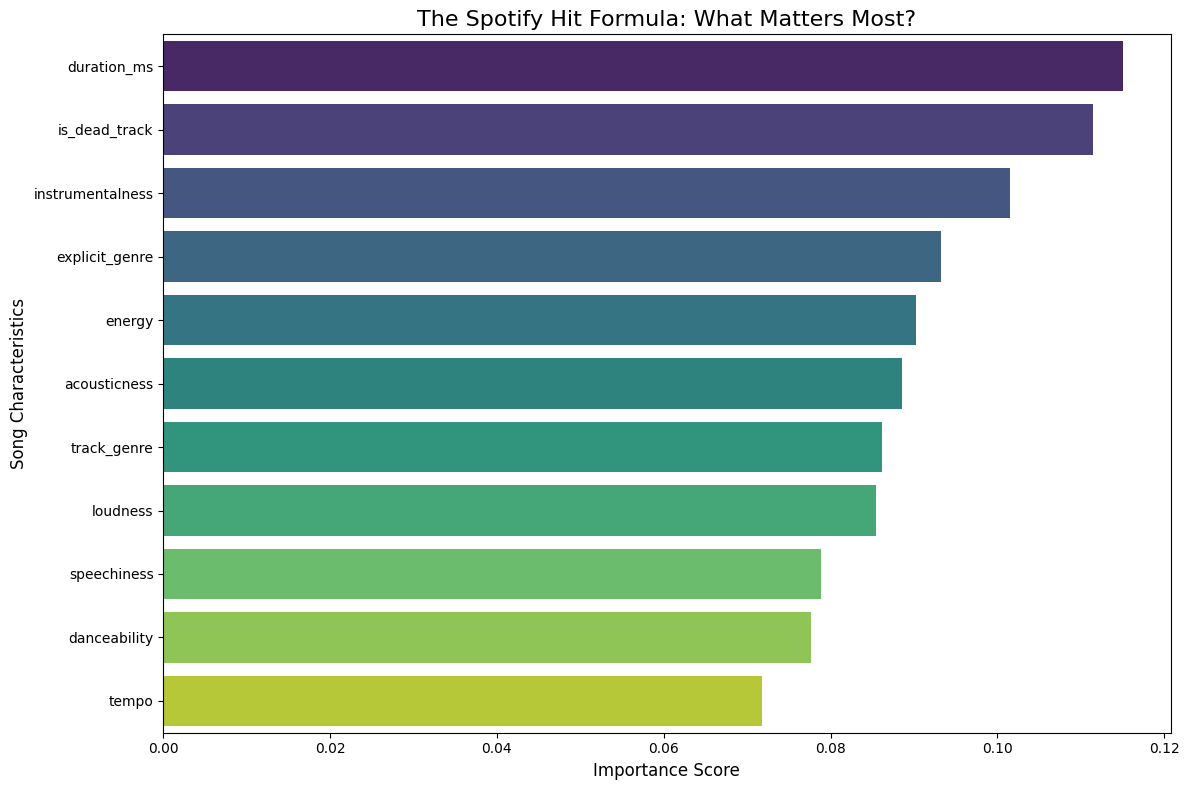

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = model_v2.feature_importances_
feature_names = x.columns
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')
plt.title('The Spotify Hit Formula: What Matters Most?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Song Characteristics', fontsize=12)

plt.tight_layout()
plt.show()

Prediction Function For The Model

In [19]:
def predict_song_status(duration_ms, genre, is_explicit,instrumentalness, energy, dead_track = 0):
   duration_ms = duration_ms * 60000

   expl_str = 'explicit' if is_explicit else 'clean'
   ex_genre_str = f"{genre}_{expl_str}"

   genre_encoded = le_genre.transform([genre])[0]
   ex_genre_encoded = le_explicit_genre.transform([ex_genre_str])[0]

   input_data = pd.DataFrame({
       'duration_ms': [duration_ms],
       'danceability': [0.5],
       'energy': [energy],
       'loudness': [-5.0],
       'speechiness': [0.05],
       'acousticness': [0.1],
       'instrumentalness': [instrumentalness],
       'tempo': [120],
       'track_genre': [genre_encoded],
       'explicit_genre': [ex_genre_encoded],
       'is_dead_track': [dead_track]
    })
   
   prediction = model_v2.predict(input_data)[0]
   return f"The model predicts this song will be a: {prediction}"

print(predict_song_status(duration_ms=3.5, genre='pop', is_explicit=False, instrumentalness=0.0, energy=0.8))

The model predicts this song will be a: Viral


In [20]:
df['duration_minutes'] = df['duration_ms'] / 60000


In [21]:
features = [
    'duration_minutes',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'tempo',
    'track_genre',
    'explicit_genre',  
]

x = df[features].copy()
y_raw = df ['popularity']

In [22]:
le_genre = LabelEncoder()
le_explicit_genre = LabelEncoder()

x['track_genre'] = le_genre.fit_transform(x['track_genre'])
x['explicit_genre'] = le_explicit_genre.fit_transform(x['explicit_genre'])

In [23]:
bins = [-1, 19, 49, 79, 100]
labels = ['Flop', 'Mid', 'Hit', 'Viral']
y = pd.cut(y_raw, bins=bins, labels=labels)

print("shape:", x.shape)
print("Class Distribution:")
print(y.value_counts())

shape: (80398, 10)
Class Distribution:
popularity
Mid      43477
Hit      18841
Flop     17541
Viral      539
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Resampled Training Class Distribution:')
print(pd.Series(y_train_resampled).value_counts())

Resampled Training Class Distribution:
popularity
Flop     34781
Mid      34781
Hit      34781
Viral    34781
Name: count, dtype: int64


In [25]:
from sklearn.metrics import classification_report

model_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v3.fit(X_train_resampled, y_train_resampled)

y_pred_v3 = model_v3.predict(X_test)
print("\nModel Evaluation Report with Duration in Minutes:")
print(classification_report(y_test, y_pred_v3))


Model Evaluation Report with Duration in Minutes:
              precision    recall  f1-score   support

        Flop       0.67      0.65      0.66      3508
         Hit       0.57      0.62      0.59      3768
         Mid       0.78      0.75      0.76      8696
       Viral       0.16      0.27      0.20       108

    accuracy                           0.69     16080
   macro avg       0.54      0.57      0.55     16080
weighted avg       0.70      0.69      0.70     16080



**Readings**

Mid is your strongest class (0.76) - the model is very good at identifying average songs. Makes sense since Mid has the most training examples.

Flop improved most (+0.10) - without the is_dead_track shortcut the model learned real audio patterns that distinguish flops.

Viral is still weak (0.20) - this is expected and honest. Viral songs defy audio patterns, which means the initial insight was correct based on the virality.

This is **69% overall acurracy**.

C:\Users\DELL\AppData\Local\Temp\ipykernel_4496\3541683577.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')


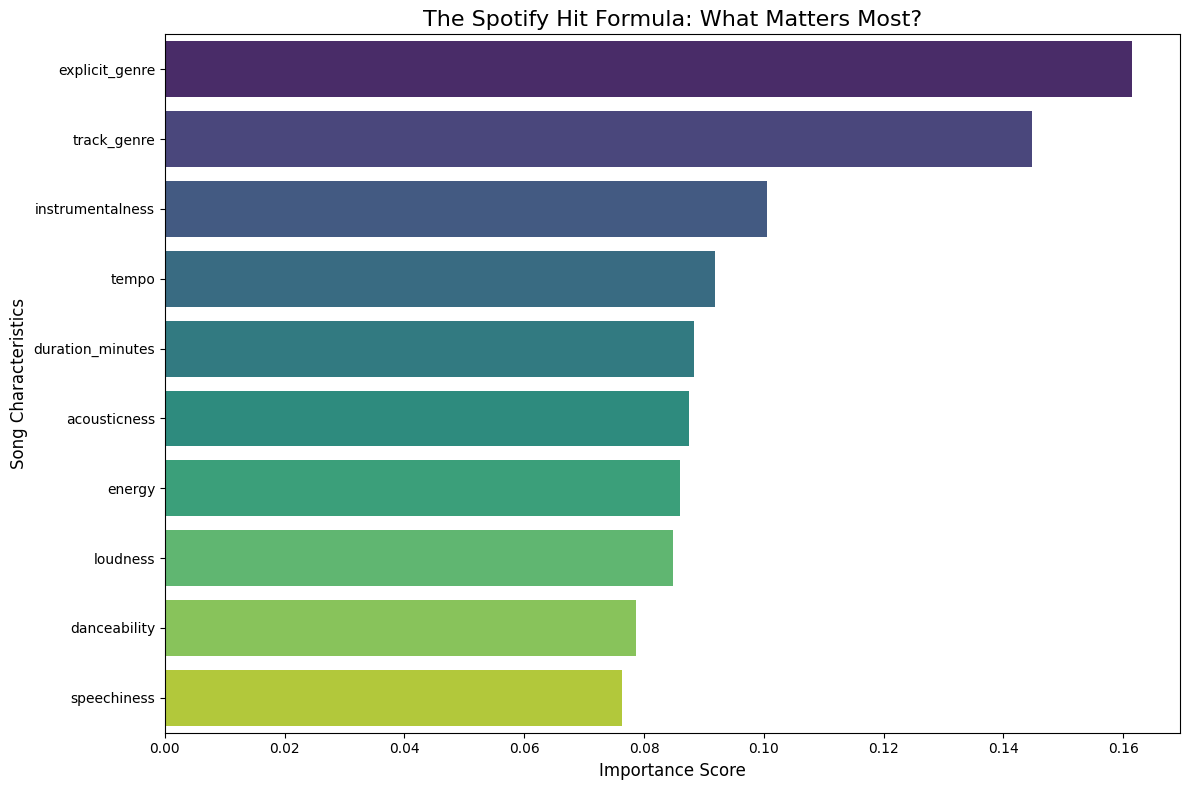

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = model_v3.feature_importances_
feature_names = x.columns
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')
plt.title('The Spotify Hit Formula: What Matters Most?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Song Characteristics', fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
def predict_song_status_v2(duration_minutes, genre, is_explicit,instrumentalness, energy, loudness, speechiness, acoustiness, danceability, tempo):
   
   explicit_str = 'explicit' if is_explicit else 'clean'
   explicit_genre_str = f"{genre}_{explicit_str}"

   genre_encoded = le_genre.transform([genre])[0]
   explicit_genre_encoded = le_explicit_genre.transform([explicit_genre_str])[0]

   input_data = pd.DataFrame({
       'duration_minutes': [duration_minutes],
       'danceability': [danceability],
       'energy': [energy],
       'loudness': [loudness],
       'speechiness': [speechiness],
       'acousticness': [acoustiness],
       'instrumentalness': [instrumentalness],
       'tempo': [tempo],
       'track_genre': [genre_encoded],
       'explicit_genre': [explicit_genre_encoded]
    })
   
   prediction = model_v3.predict(input_data)[0]
   probabilities = model_v3.predict_proba(input_data)[0]
   class_labels = model_v3.classes_

   print(f"\n Predicted Tier : {prediction}")
   print(f"Probability breakdown")
   for label, prob in zip(class_labels, probabilities):
        bar = '█' * int(prob * 20)
        print(f"  {label:<6} {bar} {prob:.1%}")


predict_song_status_v2(duration_minutes=3.5, genre='pop', is_explicit=False, instrumentalness=0.0, energy=0.8, loudness=-6.0, speechiness=0.05, acoustiness=0.1, danceability=0.7, tempo=120)


 Predicted Tier : Viral
Probability breakdown
  Flop   ████ 24.0%
  Hit    ██ 10.0%
  Mid     2.0%
  Viral  ████████████ 64.0%


In [28]:
import pickle 

with open('what-makes-a-hit-model.pkl', 'wb') as f:
    pickle.dump(model_v3, f)

print('Model v3 saved!')

Model v3 saved!


In [29]:
print(x.columns.tolist())
print(model.classes_)

['duration_minutes', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 'track_genre', 'explicit_genre']
['Flop' 'Hit' 'Mid' 'Viral']


In [30]:
print(x['track_genre'].unique()[:10])
print(x['explicit_genre'].unique()[:10])
print(x.columns.tolist())

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 7 6 8 9]
['duration_minutes', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 'track_genre', 'explicit_genre']


In [31]:
print(x['track_genre'].dtype)
print(x['explicit_genre'].dtype)

int64
int64


In [32]:
print(le.classes_)
print(df['track_genre'].unique()[:15])

['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie' 'indie-pop' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop' 'pop-film' 'power-pop'
 'progressive-house' 'psych-rock' 'punk' 'punk-rock' 'r-n-b' 'reggae'
 'reggaeton' 'rock' 'rock-n-roll' 'rockabilly' 'romance' 'sad' 'salsa'
 'samba' 'sertanejo' 'show

In [33]:
print(df[['explicit_genre', 'explicit']].head(10))


   explicit_genre  explicit
0  acoustic_clean     False
1  acoustic_clean     False
2  acoustic_clean     False
3  acoustic_clean     False
4  acoustic_clean     False
5  acoustic_clean     False
6  acoustic_clean     False
7  acoustic_clean     False
8  acoustic_clean     False
9  acoustic_clean     False


In [34]:
print((df['track_genre'] == df['explicit_genre']).all())

False


In [35]:
print(df['explicit'].unique())

[False  True]


In [36]:
print(df[['track_genre', 'explicit', 'explicit_genre']].head(20))
print(df[df['explicit']==True][['track_genre', 'explicit', 'explicit_genre']].head(10))

   track_genre  explicit  explicit_genre
0     acoustic     False  acoustic_clean
1     acoustic     False  acoustic_clean
2     acoustic     False  acoustic_clean
3     acoustic     False  acoustic_clean
4     acoustic     False  acoustic_clean
5     acoustic     False  acoustic_clean
6     acoustic     False  acoustic_clean
7     acoustic     False  acoustic_clean
8     acoustic     False  acoustic_clean
9     acoustic     False  acoustic_clean
10    acoustic     False  acoustic_clean
11    acoustic     False  acoustic_clean
12    acoustic     False  acoustic_clean
13    acoustic     False  acoustic_clean
14    acoustic     False  acoustic_clean
15    acoustic     False  acoustic_clean
16    acoustic     False  acoustic_clean
17    acoustic     False  acoustic_clean
18    acoustic     False  acoustic_clean
19    acoustic     False  acoustic_clean
    track_genre  explicit     explicit_genre
43     acoustic      True  acoustic_explicit
209    acoustic      True  acoustic_explicit
213 

In [37]:
print(df['explicit_genre'].dtype)

str


In [38]:
print(df['explicit_genre'].dtype)

print(df['explicit_genre'].unique()[:10])

import sklearn
print([x for x in dir() if 'encode' in x.lower() or 'le' in x.lower()])

str
<StringArray>
[      'acoustic_clean',    'acoustic_explicit',       'afrobeat_clean',
    'afrobeat_explicit',       'alt-rock_clean',    'alt-rock_explicit',
 'alternative_explicit',    'alternative_clean',        'ambient_clean',
     'ambient_explicit']
Length: 10, dtype: str
['LabelEncoder', 'X_train_resampled', '__vsc_ipynb_file__', 'le', 'le_explicit_genre', 'le_genre', 'pickle', 'sklearn', 'x_train_resampled', 'y_train_resampled']


In [39]:
print(x[['track_genre', 'explicit_genre']].head(5))
print(x.dtypes)

   track_genre  explicit_genre
0            0               0
1            0               0
2            0               0
3            0               0
4            0               0
duration_minutes    float64
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
tempo               float64
track_genre           int64
explicit_genre        int64
dtype: object


In [40]:
print(list(le_genre.classes_))
print(list(le_explicit_genre.classes_))

['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-rock', 'punk', 'punk-rock', 'r-n-b', 'reggae', 'reggaeton', 'rock',

In [41]:
with open('le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)

with open('le_explicit_genre.pkl', 'wb') as f:
    pickle.dump(le_explicit_genre, f)

print("Encoders saved!")

Encoders saved!


In [42]:
import pandas as pd

tier_by_genre = df.groupby(['track_genre', 'popularity_tier']).size().unstack(fill_value=0)
print(tier_by_genre)

viral_by_genre = df[df['popularity_tier'] == 'Viral']['track_genre'].value_counts()
print("\nViral songs per genre:")
print(viral_by_genre)

popularity_tier  Flop  Hit  Mid  Viral
track_genre                           
acoustic          254   84  602      1
afrobeat          746    9  198      0
alt-rock          273  242  267     16
alternative       117   89   24      8
ambient           181  101  654      1
...               ...  ...  ...    ...
techno             97   17  287      0
trance            168   21  487      0
trip-hop          407    7  447      0
turkish            11   12  826      0
world-music       173   15  692      0

[112 rows x 4 columns]

Viral songs per genre:
track_genre
dance                79
pop                  45
latino               44
hip-hop              43
rock                 28
indie-pop            18
alt-rock             16
latin                15
k-pop                14
electro              11
hard-rock            11
edm                   9
emo                   9
alternative           8
british               8
country               8
indie                 8
piano                 8
f

In [43]:
print("Danceability rannge:", x['danceability'].min(), "-", x['danceability'].max())
print("Energy range:", x['energy'].min(), "-", x['energy'].max())
print("Speechiness range:", x['speechiness'].min(), "-", x['speechiness'].max())
print("Acousticness range:", x['acousticness'].min(), "-", x['acousticness'].max())
print("Instrumentalness range:", x['instrumentalness'].min(), "-", x['instrumentalness'].max())
print("Loudness range:", x['loudness'].min(), "-", x['loudness'].max())
print("Tempo range:", x['tempo'].min(), "-", x['tempo'].max())
print("Duration range:", x['duration_minutes'].min(), "-", x['duration_minutes'].max())

Danceability rannge: 0.0 - 0.985
Energy range: 2.02e-05 - 1.0
Speechiness range: 0.0 - 0.965
Acousticness range: 0.0 - 0.996
Instrumentalness range: 0.0 - 1.0
Loudness range: -43.957 - 4.532
Tempo range: 0.0 - 243.372
Duration range: 0.1431 - 87.28825


In [44]:
if 'df_original' not in globals():
    df_original = df.copy()

duplicate_tracks = df_original.groupby('track_name')['track_genre'].apply(list)
print(duplicate_tracks[duplicate_tracks.apply(len) > 1].head(10))

track_name
#NAME?                                              [j-idol, k-pop]
'Round Midnight                                     [guitar, piano]
(Don't Fear) The Reaper                           [blues, children]
(You Make Me Feel Like) A Natural Woman         [blues, show-tunes]
0                                                       [idm, soul]
03:00:00 AM                                            [chill, sad]
04:00 AM                                   [afrobeat, anime, happy]
1 Metro e 65 - Ao Vivo                             [pagode, pagode]
1%                                                    [grunge, ska]
10,000 Reasons (Bless The Lord) - Live      [alt-rock, world-music]
Name: track_genre, dtype: object


In [45]:
if 'df_original' not in globals():
    df_original = df.copy()
print("Before dedup:", len(df_original))
print("After dedup:", len(df))
print("Rows lost:", len(df_original) - len(df))

Before dedup: 80398
After dedup: 80398
Rows lost: 0


In [46]:
import pickle

with open(r'C:\Users\DELL\Desktop\what-makes-a-hit\app\what-makes-a-hit-model.pkl', 'wb') as f:
    pickle.dump(model_v3, f)

with open(r'C:\Users\DELL\Desktop\what-makes-a-hit\app\le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)

with open(r'C:\Users\DELL\Desktop\what-makes-a-hit\app\le_explicit_genre.pkl', 'wb') as f:
    pickle.dump(le_explicit_genre, f)

print("Correct models saved!")
print("Features:", model_v3.feature_names_in_)

Correct models saved!
Features: ['duration_minutes' 'danceability' 'energy' 'loudness' 'speechiness'
 'acousticness' 'instrumentalness' 'tempo' 'track_genre' 'explicit_genre']
